In [3]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import requests  # HTTP library for Python
import bs4
import math
import xarray as xr
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import gsw
%matplotlib inline
import os
import sys
import xmitgcm 
import xgcm
import pyproj
#import wget
#sys.path.append('../../ECCOv4-py/ECCOv4-py')
#import ecco_v4_py as ecco
import cmocean
sys.path.append('/home/drdarby/Desktop/cape_mend_SM_LCS/datatools')
from datatools import datatools as tools
#from moviepy.config import change_settings
#change_settings({"FFMPEG_BINARY": "/usr/bin/ffmpeg"})
#import moviepy.video.io.ImageSequenceClip 

from scipy.fft import fft, fftfreq
from scipy.signal import periodogram
from scipy.signal import welch
from scipy.stats import chi2
from datetime import timedelta
from scipy.interpolate import griddata
from tqdm.notebook import tqdm

In [4]:
import xarray as xr
import numpy as np
from fastjmd95 import jmd95numba
from xgcm.grid import Grid

In [5]:
cutout_path = '/media/drdarby/Elements/data/Thesis/LLC4320/nc_files/cutouts/'

path_tohd = '/media/drdarby/Elements/data/Thesis/LLC4320/nc_files/'
grid_path = '/home/drdarby/Desktop/cape_mend_SM_LCS/data/cape_mend_grid_llc4320.nc'
grid = xr.open_dataset(grid_path)
variables = ['Eta','Theta','Salt','U','V','W','oceTUAX','oceTAUY']

In [ ]:
model_uv = xr.open_dataset(path_tohd + 'cutouts/uv_cape_mend_llc4320.nc').isel(k=0)

In [ ]:
model_uv

In [ ]:
salt_temp_w = xr.open_dataset(path_tohd + 'cutouts/salt_temp_w_cape_mend.nc').isel(k=0)

In [ ]:
Salt = salt_temp_w['Salt']
Temp = salt_temp_w['Theta']

In [ ]:
Density = xr.open_dataset(path_tohd + 'cutouts/density_cape_mend.nc')

In [9]:
#= jmd95numba.rho(Salt, Temp, 0)

<xarray.Dataset>
Dimensions:  (time: 9119, i: 237, j: 216)
Coordinates:
  * time     (time) datetime64[ns] 2011-11-01 ... 2012-11-14T23:00:00
  * i        (i) int64 656 657 658 659 660 661 662 ... 887 888 889 890 891 892
  * j        (j) int64 211 212 213 214 215 216 217 ... 421 422 423 424 425 426
    XC       (i, j) float32 ...
    YC       (i, j) float32 ...
    k        int64 ...
Data variables:
    Salt     (time, i, j) float64 ...

In [ ]:
(Density.isel(time=0)).plot(vmin=1024)

In [ ]:
#Density.to_netcdf(path_tohd + 'cutouts/density_cape_mend.nc')
X_uniform = np.arange(-660722,-271237,1804)
Y_uniform = np.arange(81172,465913,1624)
X_uniform_grid, Y_uniform_grid = np.meshgrid(X_uniform,Y_uniform)

test_proj_files, test_proj_filepaths =  tools.get_data_paths_from_binary('/media/drdarby/Elements/data/Thesis/LLC4320/','test-working/uv_regridded',file_end='nc')
test_proj_uni = xr.open_mfdataset(test_proj_filepaths)

naned_test = test_proj_uni.where(np.logical_or(test_proj_uni['u'].mean(dim='time')>0 ,test_proj_uni['u'].mean(dim='time')<0))
naned_test_no = naned_test.dropna(how='all',dim='time')#.dropna(how='all',dim='Y')
source_crs = 'epsg:3310'#3310 # Coordinate system of the file
target_crs = 'epsg:4326' 
latlon_to_polar = pyproj.Transformer.from_crs(source_crs,target_crs)
proj_in_lat, proj_in_lon = latlon_to_polar.transform(X_uniform_grid, Y_uniform_grid)

Land_mask = xr.DataArray(~np.isfinite(np.array(naned_test_no['u'].isel(time=0))),coords=[Y_uniform,X_uniform],dims=['Y','X'],name='land_binary_mask')
projection = xr.Dataset(data_vars = dict(projection=1),attrs=dict(earth_radius=6371000.0,proj4 = '+proj=aea +lat_1=34 +lat_2=40.5 +lat_0=0 +lon_0=-120 +x_0=0 +y_0=-4000000 +datum=NAD83 +units=m +no_defs')) 
Land_mask

#test_uv_proj = xr.merge(test_uv,projection['projection'])
projection['projection'].attrs = projection.attrs
Land_mask
Land_mask=Land_mask.where(Land_mask,0)


test_uv_proj = xr.merge([naned_test_no,projection])
Land_mask=Land_mask.where(Land_mask,0).rename('land_binary_mask')
Land_mask.attrs['grid_mapping']='epsg:3310'
Land_mask.attrs['long_name']='land_binary_mask'
Land_mask.attrs['standard_name']='land_binary_mask'
Land_mask['Y'].attrs['long_name'] = 'projection_y_coordinate'
Land_mask['Y'].attrs['units'] = 'm'
Land_mask['Y'].attrs['standard_name'] = 'projection_y_coordinate'
Land_mask['X'].attrs['long_name'] = 'projection_x_coordinate'
Land_mask['X'].attrs['units'] = 'm'
Land_mask['X'].attrs['standard_name'] = 'projection_x_coordinate'
lcs_land_mask = np.array((Land_mask.where(Land_mask<1)+1))

In [17]:
Density

<xarray.Dataset>
Dimensions:  (time: 9119, i: 237, j: 216)
Coordinates:
  * time     (time) datetime64[ns] 2011-11-01 ... 2012-11-14T23:00:00
  * i        (i) int64 656 657 658 659 660 661 662 ... 887 888 889 890 891 892
  * j        (j) int64 211 212 213 214 215 216 217 ... 421 422 423 424 425 426
    XC       (i, j) float32 ...
    YC       (i, j) float32 ...
    k        int64 ...
Data variables:
    Salt     (time, i, j) float64 ...

In [52]:
for i in tqdm(range(0,len(model_uv.time))):
    #field_v = tools.calculate_vorticity(model_uv['u'].isel(time=i),model_uv['v'].isel(time=i),model_uv['DXC'],model_uv['DYC'],model_uv['RAZ'],f)
    #field_d = tools.calculate_divergence(model_uv['u'].isel(time=i),model_uv['v'].isel(time=i),model_uv['DXC'],model_uv['DYC'],model_uv['RAZ'],f)
    field_fnt = tools.calculate_frontogenesis_function(model_uv['u'].isel(time=i),model_uv['v'].isel(time=i),Density['Salt'].isel(time=i).where(np.isfinite(lcs_land_mask)),model_uv['DXC'],model_uv['DYC'],model_uv['RAZ'])

    #field_str = tools.calculate_strain_rate(model_uv['u'].isel(time=i),model_uv['v'].isel(time=i),model_uv['DXC'],model_uv['DYC'],model_uv['RAZ'],f)
    time = [np.array(model_uv.isel(time = i).time)]
    i0 = model_uv.i[:-1]
    j0 = model_uv.j[:-1]
    #field_v = np.reshape(field_v, (1,np.shape(field_v)[0],np.shape(field_v)[1]))
    #field_d = np.reshape(field_d, (1,np.shape(field_d)[0],np.shape(field_d)[1]))
    #field_str = np.reshape(field_str, (1,np.shape(field_str)[0],np.shape(field_str)[1]))
    field_fnt = np.reshape(field_fnt, (1,np.shape(field_fnt)[0],np.shape(field_fnt)[1]))
    #vorticity = xr.DataArray(field_v, coords = [time,i0,j0], dims = ['time','i','j'], name ='vorticity')
    #divergence = xr.DataArray(field_d, coords = [time,i0,j0], dims = ['time','i','j'], name ='divergence')
    #strain_rate = xr.DataArray(field_str, coords = [time,i0,j0], dims = ['time','i','j'], name ='strain_rate')
    fronto = xr.DataArray(field_fnt, coords = [time,i0,j0],dims=['time','i','j'],name='frontogenesis_function')
    #vorticity.to_netcdf('/media/basil/Elements/data/Thesis/LLC4320/nc_files/cutouts/VORT/'+'vorticity_'+str(i).zfill(4)+'.nc')
    #divergence.to_netcdf('/media/basil/Elements/data/Thesis/LLC4320/nc_files/cutouts/DIV/'+'divergence_'+str(i).zfill(4)+'.nc')
    #strain_rate.to_netcdf('/media/basil/Elements/data/Thesis/LLC4320/nc_files/cutouts/Strain/'+'strain_'+str(i).zfill(4)+'.nc')
    fronto.to_netcdf('/media/drdarby/Elements/data/Thesis/LLC4320/nc_files/cutouts/Frontogenesis/'+'frontogenesis_'+str(i).zfill(4)+'.nc')

  0%|          | 0/9119 [00:00<?, ?it/s]

In [6]:
fronto_files, fronto_filepaths = tools.get_data_paths_from_binary(path_tohd,'cutouts/Frontogenesis',file_end='nc')

In [32]:
np.array(xr.open_mfdataset(fronto_filepaths).isel(time=0)['frontogenesis_function'])

array([[            nan,             nan,             nan, ...,
                    nan,             nan,             nan],
       [ 2.48657976e-13,  3.47752503e-13,  3.95496517e-13, ...,
                    nan,             nan,             nan],
       [ 1.40405472e-14,  1.32243642e-13,  1.69010386e-13, ...,
                    nan,             nan,             nan],
       ...,
       [ 3.11808919e-13,  2.37304928e-14, -7.16207454e-14, ...,
                    nan,             nan,             nan],
       [ 3.12424098e-13, -1.02713899e-13, -3.30164805e-13, ...,
                    nan,             nan,             nan],
       [-2.93762202e-14, -1.92749152e-13, -1.52685438e-13, ...,
                    nan,             nan,             nan]])

In [50]:
(xr.open_mfdataset(fronto_filepaths).isel(time=0)['frontogenesis_function']).close()#.plot.pcolormesh(levels=np.arange(-3,3,0.01)*10**-12,rasterized=True)

In [7]:
case_study_range_eddy = ['2012-07-05', '2012-08-31']
case_study_range_fil = ['2012-08-06', '2012-08-19']

In [8]:
frontogenesis = xr.open_mfdataset(fronto_filepaths).sel(time=slice(case_study_range_fil[0],case_study_range_fil[1]))

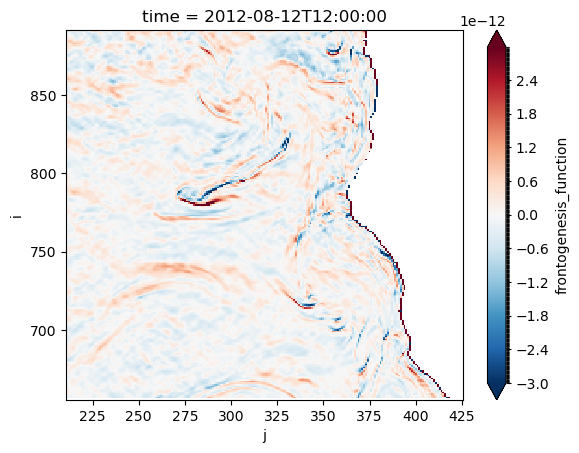

In [25]:
frontogenesis['frontogenesis_function'].isel(time=132+24).plot.pcolormesh(levels=np.arange(-3,3,0.01)*10**-12,rasterized=True)